Розмір тренувального набору: 1080 зображень.
Розмір тестового набору: 120 зображень.

--- Візуалізація перших 5 тренувальних жестів (0-4) ---


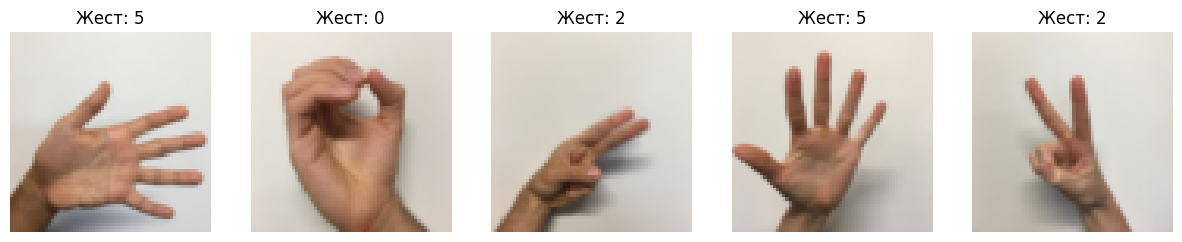


--- Перевірка розмірів після обробки ---
Форма X_train (вирівняні): (1080, 12288)
Форма Y_train (зведені): (1080,)

Початок навчання MLP...
Навчання завершено.

--- ✨ ФІНАЛЬНІ РЕЗУЛЬТАТИ РОЗПІЗНАВАННЯ ✨ ---
Точність на тренувальному наборі: 99.259% 
Точність на тестовому наборі: 84.167% 

Прогноз першого тестового жесту (індекс 0): Справжня мітка = 0, Прогноз моделі = 0


/opt/miniconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [7]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier

%matplotlib inline

# --- 1. ФУНКЦІЯ ЗАВАНТАЖЕННЯ ДАТАСЕТУ ---
def load_sign_dataset():
    """Завантажує навчальний та тестовий набори даних із файлів .h5."""
    try:
        # Завантаження навчального набору
        train_dataset = h5py.File('train_signs.h5', "r")
        X_train = np.array(train_dataset["train_set_x"][:])
        Y_train = np.array(train_dataset["train_set_y"][:])

        # Завантаження тестового набору
        test_dataset = h5py.File('test_signs.h5', "r")
        X_test = np.array(test_dataset["test_set_x"][:])
        Y_test = np.array(test_dataset["test_set_y"][:])

        # Корекція форми міток (зведення до стовпця)
        if Y_train.ndim == 1:
            Y_train = Y_train.reshape(-1, 1)
        if Y_test.ndim == 1:
            Y_test = Y_test.reshape(-1, 1)

        return X_train, Y_train, X_test, Y_test
    except Exception as e:
        print(f"ПОМИЛКА:. Деталі: {e}")
        return None, None, None, None

# --- ЗАВАНТАЖЕННЯ ДАНИХ ---
X_train_orig, Y_train_orig, X_test_orig, Y_test_orig = load_sign_dataset()

if X_train_orig is not None:
    
    # --- ВІЗУАЛІЗАЦІЯ ПРИКЛАДІВ (Щоб побачити жести) ---
    print(f"Розмір тренувального набору: {X_train_orig.shape[0]} зображень.")
    print(f"Розмір тестового набору: {X_test_orig.shape[0]} зображень.")
    print("\n--- Візуалізація перших 5 тренувальних жестів (0-4) ---")
    
    plt.figure(figsize=(15, 3))
    
    for i in range(5):
        plt.subplot(1, 5, i + 1)
        # Відображаємо оригінальне зображення
        plt.imshow(X_train_orig[i])
        # Y_train_orig[i][0] дає фактичну мітку жесту (цифру)
        plt.title(f"Жест: {Y_train_orig[i][0]}")
        plt.axis('off')
        
    plt.show()

    # --- 2. ПОПЕРЕДНЯ ОБРОБКА ДАНИХ ---
    
    m_train = X_train_orig.shape[0]
    m_test = X_test_orig.shape[0]

    # 1. Вирівнювання зображень (Flatten): (m, 64*64*3)
    X_train_flatten = X_train_orig.reshape(m_train, -1)
    X_test_flatten = X_test_orig.reshape(m_test, -1)

    # 2. Нормалізація даних (Scaling): [0, 1]
    X_train_scaled = X_train_flatten / 255.
    X_test_scaled = X_test_flatten / 255.

    # 3. Зведення міток (Squeezing) для сумісності з scikit-learn
    Y_train = np.squeeze(Y_train_orig)
    Y_test = np.squeeze(Y_test_orig)

    print("\n--- Перевірка розмірів після обробки ---")
    print(f"Форма X_train (вирівняні): {X_train_scaled.shape}")
    print(f"Форма Y_train (зведені): {Y_train.shape}")
    
    # --- 3. ПРОЕКТУВАННЯ ТА НАВЧАННЯ MLP ---
    
    # Використання MLPClassifier з конфігурацією, що забезпечила високу точність
    clf = MLPClassifier(
        hidden_layer_sizes=(100, 50), # Два приховані шари
        solver='lbfgs',               # Оптимізатор LBFGS
        random_state=42, 
        max_iter=300
    )

    print("\nПочаток навчання MLP...")
    clf.fit(X_train_scaled, Y_train)
    print("Навчання завершено.")

    # --- ОЦІНКА ТОЧНОСТІ ---
    train_accuracy = clf.score(X_train_scaled, Y_train)
    test_accuracy = clf.score(X_test_scaled, Y_test)

    print("\n--- ✨ ФІНАЛЬНІ РЕЗУЛЬТАТИ РОЗПІЗНАВАННЯ ✨ ---")
    print(f"Точність на тренувальному наборі: {train_accuracy:.3%} ")
    print(f"Точність на тестовому наборі: {test_accuracy:.3%} ")
    
    # --- ПРИКЛАД ПРОГНОЗУВАННЯ ---
    prediction = clf.predict(X_test_scaled[0].reshape(1, -1))
    print(f"\nПрогноз першого тестового жесту (індекс 0): Справжня мітка = {Y_test[0]}, Прогноз моделі = {prediction[0]}")